# Linear Transformation on Vectors

This notebook demonstrates how linear transformations work on vectors using PyTorch.

## What is a Linear Transformation?

A linear transformation is a function that maps vectors from one space to another while preserving the operations of vector addition and scalar multiplication. In other words, a function $T: \mathbb{R}^n \to \mathbb{R}^m$ is linear if it satisfies two fundamental properties.

### Mathematical Definition

A function $T: \mathbb{R}^n \to \mathbb{R}^m$ is a **linear transformation** if for all vectors $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ and all scalars $c, d \in \mathbb{R}$:

$$T(c\mathbf{u} + d\mathbf{v}) = cT(\mathbf{u}) + dT(\mathbf{v})$$

This can be broken into two properties:

1. **Additivity**: $T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v})$

2. **Homogeneity (Scalar Multiplication)**: $T(c\mathbf{u}) = cT(\mathbf{u})$

### Matrix Representation

Every linear transformation can be represented by a matrix. For a linear transformation $T: \mathbb{R}^n \to \mathbb{R}^m$, there exists a unique $m \times n$ matrix $A$ such that:

$$T(\mathbf{x}) = A\mathbf{x}$$

where $\mathbf{x} \in \mathbb{R}^n$ is the input vector and $A\mathbf{x} \in \mathbb{R}^m$ is the output vector.

**Key Properties**:

- Every linear transformation must map the zero vector to the zero vector: $T(\mathbf{0}) = \mathbf{0}$

- Linear transformations preserve vector addition: $T(\mathbf{u} + \mathbf{v}) = T(\mathbf{u}) + T(\mathbf{v})$

- Linear transformations preserve scalar multiplication: $T(c\mathbf{x}) = cT(\mathbf{x})$

- The transformation can be completely determined by its action on basis vectors

- Linear transformations can be composed: if $T_1$ and $T_2$ are linear, then $T_1 \circ T_2$ is also linear

## Matrix-Vector Multiplication: The Core of Linear Transformations

### Definition and Setup

Let $\mathbf{x}$ be a vector, i.e., $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$ and $M$ be a matrix, i.e., $M \in \mathbb{R}^{d \times d}$.

**Consider the operation**: $M\mathbf{x}$

- When a vector $\mathbf{x}$ is multiplied with a matrix, the result is a vector: $\mathbf{y} = M\mathbf{x}$
- This represents the **transformation of $\mathbf{x}$ to get a new vector $\mathbf{y}$**

### Mathematical Representation

The input vector, transformation matrix, and output vector are:

$$M\mathbf{x} = \begin{bmatrix} m_{11} & m_{12} & \cdots & m_{1d} \\ m_{21} & m_{22} & \cdots & m_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ m_{d1} & m_{d2} & \cdots & m_{dd} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix} = \begin{bmatrix} m_{11}x_1 + m_{12}x_2 + \cdots + m_{1d}x_d \\ m_{21}x_1 + m_{22}x_2 + \cdots + m_{2d}x_d \\ \vdots \\ m_{d1}x_1 + m_{d2}x_2 + \cdots + m_{dd}x_d \end{bmatrix} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_d \end{bmatrix}$$

### Element-wise Computation

Each element of the output vector is a **linear combination** of all input elements:

$$y_1 = m_{11}x_1 + m_{12}x_2 + \cdots + m_{1d}x_d$$

$$y_2 = m_{21}x_1 + m_{22}x_2 + \cdots + m_{2d}x_d$$

$$\vdots$$

$$y_d = m_{d1}x_1 + m_{d2}x_2 + \cdots + m_{dd}x_d$$

**General Formula**: The $i$-th element of the output vector is computed as:

$$y_i = \sum_{j=1}^{d} m_{ij}x_j = m_{i1}x_1 + m_{i2}x_2 + \cdots + m_{id}x_d$$

### The Core of Linear Transformations

**Key Characteristics**:

- **Elements of vector $\mathbf{x}$ are linearly related with elements of the resultant vector $\mathbf{y}$**
  
- Each output element $y_i$ is formed as a **weighted sum** of input elements, where weights are matrix entries $m_{ij}$
  
- The transformation is **linear** because:
  - No nonlinear operations (like squaring or exponentials) are involved
  - Each output is a first-degree polynomial in the input variables
  - The operations preserve vector addition and scalar multiplication
  
- Every linear transformation can be represented by a matrix, and every matrix represents a linear transformation

In [10]:
import torch
import numpy as np

# Demonstrate: y = M x where each element of y is a linear combination of x elements

print("="*70)
print("LINEAR TRANSFORMATION: y = M x")
print("="*70)

# Define vector x
x = torch.tensor([2.0, 3.0, 1.0])  # d = 3
print(f"\nInput vector x ∈ ℝ³:")
print(f"x = {x.tolist()}")

# Define transformation matrix M (3 x 3)
M = torch.tensor([
    [2.0, 1.0, 0.5],    # Row 1: coefficients for y₁
    [1.0, 3.0, 1.0],    # Row 2: coefficients for y₂
    [0.5, 0.0, 2.0]     # Row 3: coefficients for y₃
])
print(f"\nTransformation matrix M ∈ ℝ³×³:")
print(M)

# Apply linear transformation: y = M x
y = torch.matmul(M, x)
print(f"\nResult vector y = M x:")
print(f"y = {y.tolist()}")

# Show the linear combinations explicitly
print(f"\n" + "="*70)
print("ELEMENT-WISE LINEAR COMBINATIONS")
print("="*70)

print(f"\nEach element of y is a linear combination of all elements of x:")
print(f"\ny₁ = m₁₁·x₁ + m₁₂·x₂ + m₁₃·x₃")
print(f"   = {M[0,0]:.1f}·{x[0]:.1f} + {M[0,1]:.1f}·{x[1]:.1f} + {M[0,2]:.1f}·{x[2]:.1f}")
print(f"   = {M[0,0]*x[0]:.1f} + {M[0,1]*x[1]:.1f} + {M[0,2]*x[2]:.1f}")
print(f"   = {y[0]:.1f}")

print(f"\ny₂ = m₂₁·x₁ + m₂₂·x₂ + m₂₃·x₃")
print(f"   = {M[1,0]:.1f}·{x[0]:.1f} + {M[1,1]:.1f}·{x[1]:.1f} + {M[1,2]:.1f}·{x[2]:.1f}")
print(f"   = {M[1,0]*x[0]:.1f} + {M[1,1]*x[1]:.1f} + {M[1,2]*x[2]:.1f}")
print(f"   = {y[1]:.1f}")

print(f"\ny₃ = m₃₁·x₁ + m₃₂·x₂ + m₃₃·x₃")
print(f"   = {M[2,0]:.1f}·{x[0]:.1f} + {M[2,1]:.1f}·{x[1]:.1f} + {M[2,2]:.1f}·{x[2]:.1f}")
print(f"   = {M[2,0]*x[0]:.1f} + {M[2,1]*x[1]:.1f} + {M[2,2]*x[2]:.1f}")
print(f"   = {y[2]:.1f}")

print(f"\n" + "="*70)
print("KEY INSIGHT")
print("="*70)
print(f"\nElements of vector x are LINEARLY RELATED with elements of y:")
print(f"  • Each y_i is a weighted sum of all x_j")
print(f"  • Weights are the matrix entries m_ij")
print(f"  • This is the essence of LINEAR TRANSFORMATION")
print(f"\nNo nonlinear operations (squaring, exponentials, etc.) involved!")
print(f"Each output is a first-degree polynomial in the input variables.")

LINEAR TRANSFORMATION: y = M x

Input vector x ∈ ℝ³:
x = [2.0, 3.0, 1.0]

Transformation matrix M ∈ ℝ³×³:
tensor([[2.0000, 1.0000, 0.5000],
        [1.0000, 3.0000, 1.0000],
        [0.5000, 0.0000, 2.0000]])

Result vector y = M x:
y = [7.5, 12.0, 3.0]

ELEMENT-WISE LINEAR COMBINATIONS

Each element of y is a linear combination of all elements of x:

y₁ = m₁₁·x₁ + m₁₂·x₂ + m₁₃·x₃
   = 2.0·2.0 + 1.0·3.0 + 0.5·1.0
   = 4.0 + 3.0 + 0.5
   = 7.5

y₂ = m₂₁·x₁ + m₂₂·x₂ + m₂₃·x₃
   = 1.0·2.0 + 3.0·3.0 + 1.0·1.0
   = 2.0 + 9.0 + 1.0
   = 12.0

y₃ = m₃₁·x₁ + m₃₂·x₂ + m₃₃·x₃
   = 0.5·2.0 + 0.0·3.0 + 2.0·1.0
   = 1.0 + 0.0 + 2.0
   = 3.0

KEY INSIGHT

Elements of vector x are LINEARLY RELATED with elements of y:
  • Each y_i is a weighted sum of all x_j
  • Weights are the matrix entries m_ij
  • This is the essence of LINEAR TRANSFORMATION

No nonlinear operations (squaring, exponentials, etc.) involved!
Each output is a first-degree polynomial in the input variables.


## Common Types of Linear Transformations

**Rotation**: Rotates vectors by an angle $\theta$
$$R(\theta) = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

**Scaling**: Scales vectors by factors $s_1, s_2, \ldots, s_n$
$$S = \begin{bmatrix} s_1 & 0 & \cdots & 0 \\ 0 & s_2 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & s_n \end{bmatrix}$$

**Reflection**: Reflects vectors across an axis or hyperplane
$$H = \begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix} \quad \text{(reflection across y-axis)}$$

**Projection**: Projects vectors onto a subspace
$$P = \mathbf{u}\mathbf{u}^T \quad \text{(projection onto unit vector } \mathbf{u}\text{)}$$

**Shear**: Shears vectors by moving them parallel to a line or plane

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Create a simple 2D vector
v = torch.tensor([2.0, 1.0])

# Create a linear transformation matrix (2x2)
A = torch.tensor([
    [2.0, 0.5],
    [0.0, 1.5]
])

print(f"Original vector v: {v}")
print(f"\nTransformation matrix A:")
print(A)
print(f"\nMatrix shape: {A.shape}")

Original vector v: tensor([2., 1.])

Transformation matrix A:
tensor([[2.0000, 0.5000],
        [0.0000, 1.5000]])

Matrix shape: torch.Size([2, 2])


In [12]:
# Apply linear transformation
transformed_v = torch.matmul(A, v)

print(f"Transformed vector v' = A·v: {transformed_v}")
print(f"\nCalculation:")
print(f"  v'[0] = 2*2 + 0.5*1 = {transformed_v[0]}")
print(f"  v'[1] = 0*2 + 1.5*1 = {transformed_v[1]}")

Transformed vector v' = A·v: tensor([4.5000, 1.5000])

Calculation:
  v'[0] = 2*2 + 0.5*1 = 4.5
  v'[1] = 0*2 + 1.5*1 = 1.5


In [13]:
# Verify linear transformation properties
print("Verifying Linear Transformation Properties\n")

# Property 1: Zero vector maps to zero vector
zero_vec = torch.tensor([0.0, 0.0])
transformed_zero = torch.matmul(A, zero_vec)
print(f"Property 1 - Zero vector:")
print(f"  T(0) = {transformed_zero}")
print(f"  Is it zero? {torch.allclose(transformed_zero, torch.zeros(2))}\n")

# Property 2: Additivity - T(u + v) = T(u) + T(v)
u = torch.tensor([1.0, 1.0])
v = torch.tensor([2.0, 1.0])

T_u_plus_v = torch.matmul(A, u + v)
T_u = torch.matmul(A, u)
T_v = torch.matmul(A, v)
T_u_plus_T_v = T_u + T_v

print(f"Property 2 - Additivity:")
print(f"  u = {u}, v = {v}")
print(f"  T(u + v) = {T_u_plus_v}")
print(f"  T(u) + T(v) = {T_u_plus_T_v}")
print(f"  Are they equal? {torch.allclose(T_u_plus_v, T_u_plus_T_v)}\n")

# Property 3: Homogeneity - T(c*u) = c*T(u)
c = 3.0
T_cu = torch.matmul(A, c * u)
c_T_u = c * torch.matmul(A, u)

print(f"Property 3 - Homogeneity (Scalar Multiplication):")
print(f"  u = {u}, c = {c}")
print(f"  T(c*u) = {T_cu}")
print(f"  c*T(u) = {c_T_u}")
print(f"  Are they equal? {torch.allclose(T_cu, c_T_u)}")

Verifying Linear Transformation Properties

Property 1 - Zero vector:
  T(0) = tensor([0., 0.])
  Is it zero? True

Property 2 - Additivity:
  u = tensor([1., 1.]), v = tensor([2., 1.])
  T(u + v) = tensor([7., 3.])
  T(u) + T(v) = tensor([7., 3.])
  Are they equal? True

Property 3 - Homogeneity (Scalar Multiplication):
  u = tensor([1., 1.]), c = 3.0
  T(c*u) = tensor([7.5000, 4.5000])
  c*T(u) = tensor([7.5000, 4.5000])
  Are they equal? True


## 2D Rotation Transformation

In [14]:
# Rotation transformation by angle theta
theta = torch.tensor(np.pi / 4)  # 45 degrees

# Rotation matrix
cos_theta = torch.cos(theta)
sin_theta = torch.sin(theta)

R = torch.tensor([
    [cos_theta, -sin_theta],
    [sin_theta, cos_theta]
])

print(f"Rotation angle: {torch.rad2deg(theta):.2f}°")
print(f"\nRotation matrix R:")
print(R)

# Original vector
v = torch.tensor([1.0, 0.0])
v_rotated = torch.matmul(R, v)

print(f"\nOriginal vector: {v}")
print(f"Rotated vector: {v_rotated}")
print(f"Angle of rotated vector: {torch.rad2deg(torch.atan2(v_rotated[1], v_rotated[0])):.2f}°")

Rotation angle: 45.00°

Rotation matrix R:
tensor([[ 0.7071, -0.7071],
        [ 0.7071,  0.7071]])

Original vector: tensor([1., 0.])
Rotated vector: tensor([0.7071, 0.7071])
Angle of rotated vector: 45.00°


## 2D Scaling Transformation

In [15]:
# Scaling transformation
scale_x = 2.0
scale_y = 0.5

S = torch.tensor([
    [scale_x, 0.0],
    [0.0, scale_y]
])

print(f"Scaling matrix S (scale_x={scale_x}, scale_y={scale_y}):")
print(S)

# Original vector
v = torch.tensor([1.0, 1.0])
v_scaled = torch.matmul(S, v)

print(f"\nOriginal vector: {v}")
print(f"Scaled vector: {v_scaled}")
print(f"\nMagnitude before scaling: {torch.norm(v):.4f}")
print(f"Magnitude after scaling: {torch.norm(v_scaled):.4f}")

Scaling matrix S (scale_x=2.0, scale_y=0.5):
tensor([[2.0000, 0.0000],
        [0.0000, 0.5000]])

Original vector: tensor([1., 1.])
Scaled vector: tensor([2.0000, 0.5000])

Magnitude before scaling: 1.4142
Magnitude after scaling: 2.0616


## 2D Reflection Transformation

In [16]:
# Reflection across x-axis
H_x = torch.tensor([
    [1.0, 0.0],
    [0.0, -1.0]
])

# Reflection across y-axis
H_y = torch.tensor([
    [-1.0, 0.0],
    [0.0, 1.0]
])

# Reflection across line y = x
H_diag = torch.tensor([
    [0.0, 1.0],
    [1.0, 0.0]
])

v = torch.tensor([2.0, 3.0])

print(f"Original vector: {v}\n")

v_reflect_x = torch.matmul(H_x, v)
print(f"Reflection across x-axis: {v_reflect_x}")

v_reflect_y = torch.matmul(H_y, v)
print(f"Reflection across y-axis: {v_reflect_y}")

v_reflect_diag = torch.matmul(H_diag, v)
print(f"Reflection across y=x line: {v_reflect_diag}")

Original vector: tensor([2., 3.])

Reflection across x-axis: tensor([ 2., -3.])
Reflection across y-axis: tensor([-2.,  3.])
Reflection across y=x line: tensor([3., 2.])


## Composition of Linear Transformations

In [17]:
# Composition: First rotate, then scale
theta = torch.tensor(np.pi / 6)  # 30 degrees
cos_t = torch.cos(theta)
sin_t = torch.sin(theta)

R = torch.tensor([
    [cos_t, -sin_t],
    [sin_t, cos_t]
])

S = torch.tensor([
    [2.0, 0.0],
    [0.0, 1.5]
])

# Composition: Apply rotation first, then scaling
v = torch.tensor([1.0, 0.0])

v_rotated = torch.matmul(R, v)
v_final = torch.matmul(S, v_rotated)

print(f"Original vector: {v}")
print(f"After rotation: {v_rotated}")
print(f"After scaling: {v_final}")

# Composition matrix (scale × rotate)
Composed = torch.matmul(S, R)

v_direct = torch.matmul(Composed, v)
print(f"\nDirect composition (S·R)·v: {v_direct}")
print(f"Are they equal? {torch.allclose(v_final, v_direct)}")

Original vector: tensor([1., 0.])
After rotation: tensor([0.8660, 0.5000])
After scaling: tensor([1.7321, 0.7500])

Direct composition (S·R)·v: tensor([1.7321, 0.7500])
Are they equal? True


## Visualization of Linear Transformations

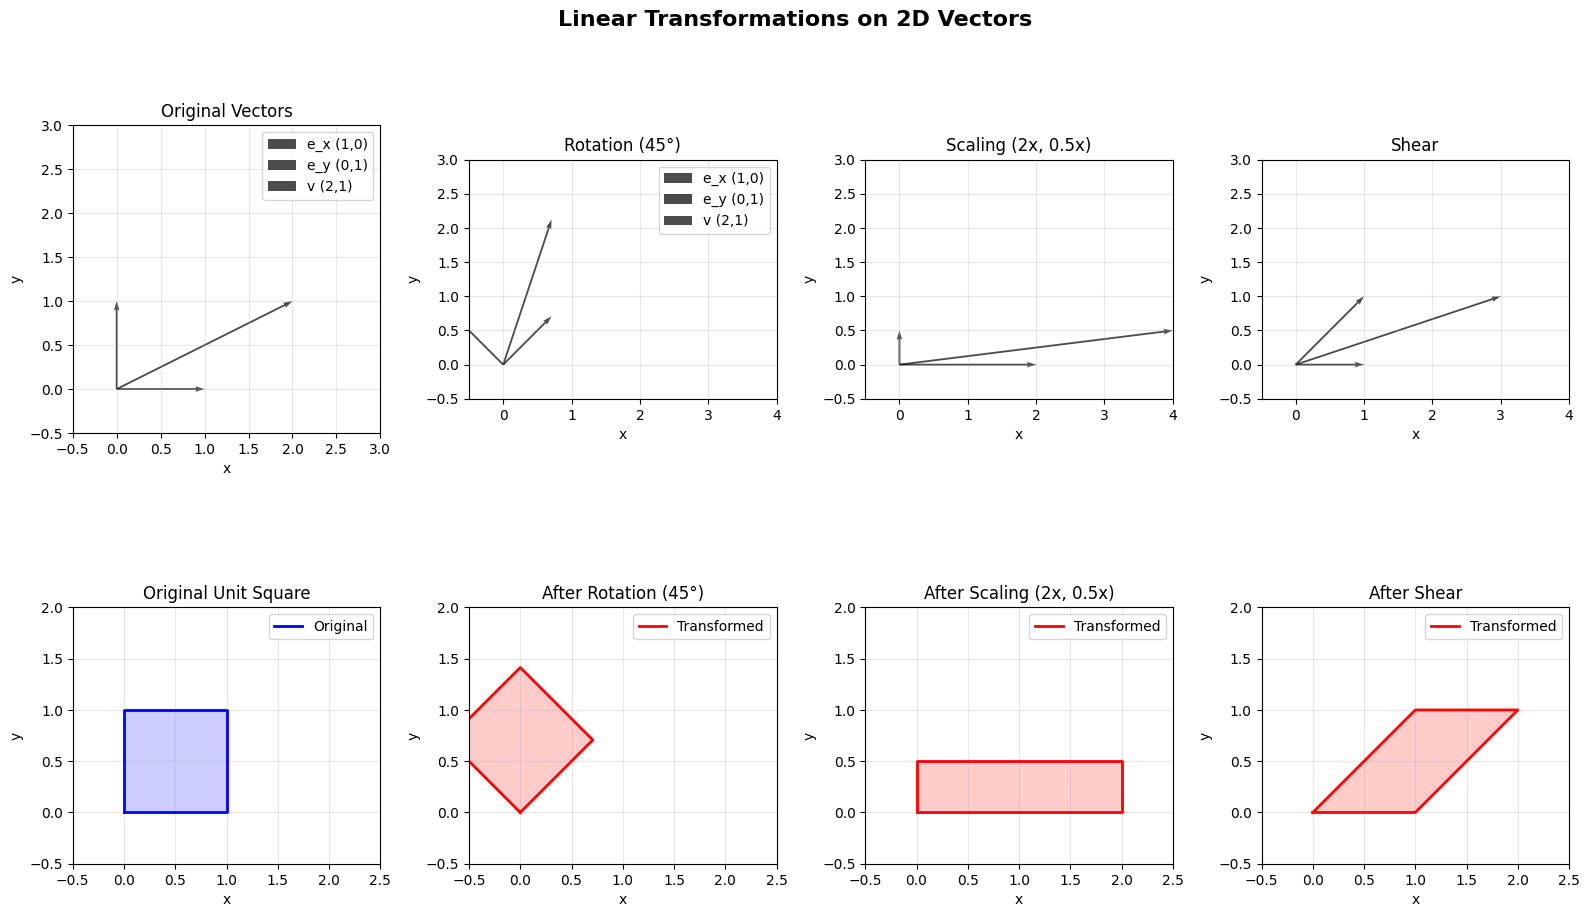

In [20]:
# Visualize different linear transformations
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Linear Transformations on 2D Vectors', fontsize=16, fontweight='bold')

# Original vectors (basis vectors and their combination)
basis_x = torch.tensor([1.0, 0.0])
basis_y = torch.tensor([0.0, 1.0])
v_combo = torch.tensor([2.0, 1.0])

original_vectors = [basis_x, basis_y, v_combo]
original_labels = ['e_x (1,0)', 'e_y (0,1)', 'v (2,1)']

# Define transformations
transformations = []

# 1. Rotation 45 degrees
theta = torch.tensor(np.pi / 4)
cos_t = torch.cos(theta)
sin_t = torch.sin(theta)
R = torch.tensor([[cos_t, -sin_t], [sin_t, cos_t]])
transformations.append((R, 'Rotation (45°)'))

# 2. Scaling (2x in x, 0.5x in y)
S = torch.tensor([[2.0, 0.0], [0.0, 0.5]])
transformations.append((S, 'Scaling (2x, 0.5x)'))

# 3. Shear
Sh = torch.tensor([[1.0, 1.0], [0.0, 1.0]])
transformations.append((Sh, 'Shear'))

# Plot original vectors
ax = axes[0, 0]
for i, vec in enumerate(original_vectors):
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, 
             width=0.006, label=original_labels[i], alpha=0.7)
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original Vectors')
ax.legend()

# Plot transformed vectors
for idx, (matrix, title) in enumerate(transformations):
    ax = axes[0, idx+1]
    for i, vec in enumerate(original_vectors):
        transformed = torch.matmul(matrix, vec)
        ax.quiver(0, 0, transformed[0], transformed[1], angles='xy', scale_units='xy', 
                 scale=1, width=0.006, label=original_labels[i], alpha=0.7)
    ax.set_xlim(-0.5, 4)
    ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    if idx == 0:
        ax.legend()

# Second row: Show transformation of unit square
square_vertices = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
    [0.0, 0.0]
])

# Plot original square
ax = axes[1, 0]
ax.plot(square_vertices[:, 0], square_vertices[:, 1], 'b-', linewidth=2, label='Original')
ax.fill(square_vertices[:-1, 0], square_vertices[:-1, 1], alpha=0.2, color='blue')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Original Unit Square')
ax.legend()

# Plot transformed squares
for idx, (matrix, title) in enumerate(transformations):
    ax = axes[1, idx+1]
    transformed_square = torch.matmul(square_vertices, matrix.T)
    ax.plot(transformed_square[:, 0], transformed_square[:, 1], 'r-', linewidth=2, label='Transformed')
    ax.fill(transformed_square[:-1, 0], transformed_square[:-1, 1], alpha=0.2, color='red')
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'After {title}')
    ax.legend()

plt.tight_layout()
plt.show()

## Change of Basis

In [21]:
# Change of basis example
print("Change of Basis Example\n")

# Original basis (standard basis)
E = torch.eye(2)
print(f"Standard basis E:")
print(E)

# New basis vectors
e1_new = torch.tensor([1.0, 1.0]) / torch.sqrt(torch.tensor(2.0))  # normalized
e2_new = torch.tensor([-1.0, 1.0]) / torch.sqrt(torch.tensor(2.0))  # normalized

# Change of basis matrix (columns are new basis vectors in old coordinates)
P = torch.stack([e1_new, e2_new], dim=1)

print(f"\nNew basis P (45° rotated basis):")
print(P)

# Vector in standard basis
v_standard = torch.tensor([2.0, 1.0])

# Express v in the new basis: v_new = P^(-1) * v_standard
P_inv = torch.linalg.inv(P)
v_new = torch.matmul(P_inv, v_standard)

print(f"\nVector in standard basis: {v_standard}")
print(f"Vector in new basis: {v_new}")
print(f"\nVerification (P * v_new should equal v_standard):")
print(f"P * v_new = {torch.matmul(P, v_new)}")
print(f"Are they equal? {torch.allclose(torch.matmul(P, v_new), v_standard)}")

Change of Basis Example

Standard basis E:
tensor([[1., 0.],
        [0., 1.]])

New basis P (45° rotated basis):
tensor([[ 0.7071, -0.7071],
        [ 0.7071,  0.7071]])

Vector in standard basis: tensor([2., 1.])
Vector in new basis: tensor([ 2.1213, -0.7071])

Verification (P * v_new should equal v_standard):
P * v_new = tensor([2.0000, 1.0000])
Are they equal? True


## Applications of Linear Transformations

**Computer Graphics:**
- Rotations, scalings, and translations of objects
- Perspective projections and 3D transformations
- Camera transformations and coordinate systems

**Machine Learning:**
- Neural network layers (linear transformations followed by activations)
- Principal Component Analysis (PCA) for dimensionality reduction
- Feature extraction and representation learning

**Image Processing:**
- Filtering and convolutions
- Image rotation and scaling
- Geometric corrections

**Physics and Engineering:**
- Change of reference frames
- Stress and strain transformations
- Coordinate system transformations

**Data Analysis:**
- Whitening data (covariance matrix transformation)
- Coordinate system alignment
- Basis transformations for different representations

**Signal Processing:**
- Fourier transforms (linear transformations to frequency domain)
- Filtering operations
- Time-frequency transformations